# Notebook 4: Brownian Motion on the Hyperbolic Disk $H^2$

The Poincare disk model represents the hyperbolic plane $H^2$ as the open unit disk
$D = \{(x,y) : x^2+y^2 < 1\}$, equipped with the conformal metric

$$
ds^2 = \lambda(x,y)^2 (dx^2+dy^2), \qquad \lambda(x,y) = \frac{2}{1-x^2-y^2}
$$

Unlike the Sphere and Torus, $H^2$ has no isometric embedding into $\mathbb{R}^3$ (Hilbert's
theorem), so points here are 2D vectors, and the projection method used for the other two surfaces does not directly apply. Every formula used below is derived in `docs/writeups/2-poincare-disk-derivation.md`, starting from the convention that Brownian motion's generator is half the Laplace-Beltrami operator.

In [10]:
# Imports
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.stats import kstest

import sys
sys.path.append("..")
from src.manifolds.hyperbolic import PoincareDisk
from src.simulation.simulator import hyperbolic_simulator

## Structural checks

Before any statistics, we check the basic structural properties that hold by
construction:

- `project_to_tangent(x, v)` must return `v` unchanged, since $H^2$ is intrinsically 2-dimensional (every tangent space is all of $\mathbb{R}^2$ -- see
  `docs/writeups/2-poincare-disk-derivation.md` section 5 in `hyperbolic.py`.
- `project_to_manifold` must be idempotent, and must leave points already well inside the disk unchanged.
- `project_to_manifold` must "clamp" a point placed outside (or on) the unit circle back to radius $1-\varepsilon$ and preserve its angle.

In [11]:
disk = PoincareDisk()
rng = np.random.default_rng(0)

def random_interior_point(rng, max_radius=0.9):
    """Samples a point genuinely inside the disk via polar coordinates
    (sampling x, y independently and uniformly can land outside the unit
    disk, e.g. (0.9, 0.9) has norm ~1.27 > 1)."""
    radius = rng.uniform(0.0, max_radius)
    angle = rng.uniform(0.0, 2 * np.pi)
    return radius * np.array([np.cos(angle), np.sin(angle)])

# project_to_tangent identical
for _ in range(20):
    x = random_interior_point(rng)
    v = rng.normal(size=2)
    assert np.array_equal(disk.project_to_tangent(x, v), v)

# project_to_manifold leaves interior points unchanged
for _ in range(20):
    x = random_interior_point(rng)
    assert np.allclose(disk.project_to_manifold(x), x)

# project_to_manifold is idempotent
for _ in range(20):
    x = random_interior_point(rng, max_radius=0.999)
    once = disk.project_to_manifold(x)
    twice = disk.project_to_manifold(once)
    assert np.allclose(once, twice)

# project_to_manifold bounds a point beyond the boundary to radius 1 - epsilon,
# preserving its angle
for _ in range(20):
    angle = rng.uniform(0, 2 * np.pi)
    over_radius = rng.uniform(1.0, 5.0)
    x = over_radius * np.array([np.cos(angle), np.sin(angle)])
    bounded = disk.project_to_manifold(x)
    assert np.isclose(np.linalg.norm(bounded), 1.0 - disk.epsilon)
    assert np.isclose(np.arctan2(bounded[1], bounded[0]), np.arctan2(x[1], x[0]))

print("All structural checks passed.")

All structural checks passed.


## Constraining the domain

The true continuous-time process never reaches the boundary $|x|=1$ in finite time (it is transient to infinite geodesic distance, see
`docs/writeups/2-poincare-disk-derivation.md` section 6). The rescaling in `project_to_manifold` exists only to protect against floating-point error in the discrete Euler-Maruyama scheme. We run a long single-particle simulation and check (1) every point stays inside the disk, and (2) the rescaling trigger is called decreasingly at a rate that shrinks as `dt` does.

In [12]:
def run_single_path(T, dt, epsilon=1e-10):
    """Runs one particle's path (rather than via euler_maruyama_step)
    so we can check every point stays inside the disk."""
    local_disk = PoincareDisk(epsilon=epsilon)
    x = np.array([0.0, 0.0])
    path = [x.copy()]
    for _ in range(T):
        noise = local_disk.sample_tangent_noise(x)
        x = local_disk.project_to_manifold(x + np.sqrt(dt) * noise)
        path.append(x.copy())
    return np.array(path)

T_long = 100_000
path = run_single_path(T_long, dt=0.01)
radii = np.linalg.norm(path, axis=1)
assert np.all(radii < 1.0)
print(f"Domain constraint held for all {T_long} steps. Max radius reached: {radii.max():.10f}")

def clamp_rate(N, total_time, dt, epsilon=1e-10):
    """Runs an ensemble of N particles for total_time/dt steps and returns the
    fraction of individual particle-steps whose proposed step would have landed
    at or beyond 1 - epsilon before the rescaling measure corrects it."""
    local_disk = PoincareDisk(epsilon=epsilon)
    T = int(total_time / dt)
    points = np.tile(np.array([0.0, 0.0]), (N, 1))
    triggers = 0
    for _ in range(T):
        noise = local_disk.sample_tangent_noise_multiple(points)
        proposed = points + np.sqrt(dt) * noise
        triggers += int(np.sum(np.linalg.norm(proposed, axis=1) >= 1.0 - epsilon))
        points = local_disk.project_to_manifold_multiple(proposed)
    return triggers / (N * T)

print()
print("Rescaling rate as dt shrinks (1000 particles, total elapsed time t = 50):")
for dt_i in [0.05, 0.01, 0.005, 0.001]:
    rate = clamp_rate(N=1000, total_time=50, dt=dt_i)
    print(f"  dt={dt_i:<7} rate={rate:.3e}")

Domain constraint held for all 100000 steps. Max radius reached: 0.9999999999

Rescaling rate as dt shrinks (1000 particles, total elapsed time t = 50):
  dt=0.05    rate=3.405e-02
  dt=0.01    rate=1.315e-02
  dt=0.005   rate=9.303e-03
  dt=0.001   rate=4.149e-03


## Trajectory visualization

Here, we visualize a single path plotted in the disk together with the unit circle boundary. We expect this path to be consistent with transience, meaning the path should drift outward over time.

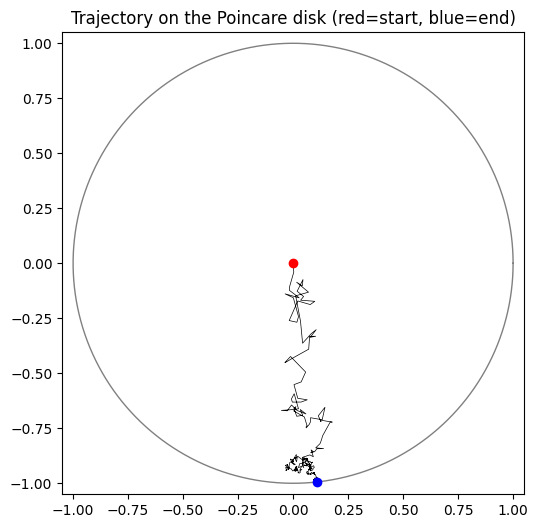

In [13]:
theta_circle = np.linspace(0, 2 * np.pi, 200)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(np.cos(theta_circle), np.sin(theta_circle), color="gray", linewidth=1)
ax.plot(path[:, 0], path[:, 1], color="black", linewidth=0.5)
ax.plot(path[0, 0], path[0, 1], "o", color="red", markersize=6)
ax.plot(path[-1, 0], path[-1, 1], "o", color="blue", markersize=6)
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_aspect("equal")
ax.set_title("Trajectory on the Poincare disk (red=start, blue=end)")
plt.show()

## SDE coefficient recovery

`docs/writeups/2-poincare-disk-derivation.md` derives, from our generator convention, that the radial process $\rho_t = 2\,\mathrm{tanh}^{-1}(|X_t|)$ satisfies

$$
d\rho_t = d\beta_t + \tfrac{1}{2}\coth(\rho_t)\,dt
$$

i.e. unit diffusion coefficient and drift $\tfrac12\coth(\rho)$. We simulate many independent particles, and at every step the current $\rho$ and accumulate the count, sum, and sum of squares of the increment $\Delta\rho$ per bin. Afterward we compare the local drift $E[\Delta\rho\mid\rho]/dt$ and diffusion
$\mathrm{Var}[\Delta\rho\mid\rho]/dt$ against closed-form values.

**A key finding**: Using `dt=0.01` (the value used throughout the rest of the notebook) recovered drift correctly, but the diffusion coefficient came out consistently ~2-3% high which is too large to be sampling noise given our involved sample sizes. Halving `dt` repeatedly (0.01, 0.005, 0.0025, 0.00125, ...) shrank bias (roughly) proportional each time (2.36%, 1.19%, 0.54%, 0.21%, ...), which is expected per Euler-Maruyama's known weak-order-1 discretization bias (`docs/writeups/1-curriculum-checklist.md` §"Euler-Maruyama Convergence": *"weak order 1"*, i.e. an $O(dt)$ error in expectations of smooth functionals) acting on the nonlinear transform $\rho(x)$ of a discretely-simulated path. That the bias shrinks linearly with `dt`, as the convergence theorem predicts, is itself a measure of consistency. Hence we use `dt=0.0005` below so bias is small.

We also exclude the bin nearest $\rho=0$ as this is a point which $\coth(\rho)$ diverges, so a bin of finite width poorly approximates the theory curve by its center (the small-$\rho$ limit is checked separately, and exactly, in
`docs/writeups/2-poincare-disk-derivation.md` section 5b via the Bessel(2) matching).

In [14]:
def radial_coefficient_recovery(N, T, dt, bin_edges):
    """Simulates N particles for T steps of size dt, and for each step bins
    the *current* rho value and accumulates count / sum / sum-of-squares of
    the increment delta_rho within that bin."""
    local_disk = PoincareDisk()
    n_bins = len(bin_edges) - 1
    points = np.tile(np.array([0.0, 0.0]), (N, 1))
    rho = local_disk.geodesic_distance_from_origin_multiple(points)
    counts = np.zeros(n_bins)
    sums = np.zeros(n_bins)
    sumsqs = np.zeros(n_bins)
    for _ in range(T):
        noise = local_disk.sample_tangent_noise_multiple(points)
        points_new = points + np.sqrt(dt) * noise
        points_new = local_disk.project_to_manifold_multiple(points_new)
        rho_new = local_disk.geodesic_distance_from_origin_multiple(points_new)
        delta_rho = rho_new - rho
        bin_idx = np.digitize(rho, bin_edges) - 1
        valid = (bin_idx >= 0) & (bin_idx < n_bins)
        np.add.at(counts, bin_idx[valid], 1)
        np.add.at(sums, bin_idx[valid], delta_rho[valid])
        np.add.at(sumsqs, bin_idx[valid], delta_rho[valid] ** 2)
        points, rho = points_new, rho_new
    return counts, sums, sumsqs

dt_fine = 0.0005
bin_edges = np.linspace(1.0, 18.0, 18)  # excludes [0, 1) -- see markdown above
counts, sums, sumsqs = radial_coefficient_recovery(N=4000, T=40_000, dt=dt_fine, bin_edges=bin_edges)

print(f"{'rho range':<16}{'n':<10}{'drift (emp)':<14}{'drift (theory)':<16}{'within k*SE':<13}"
      f"{'diffusion (emp)':<18}{'within k*SE'}")

k = 6  # generous multiple of standard error
all_ok = True
recovered_rho_centers, recovered_drifts, recovered_theory_drifts = [], [], []
for b in range(len(bin_edges) - 1):
    n = counts[b]
    if n < 500:
        continue
    mean_delta_rho = sums[b] / n
    var_delta_rho = (sumsqs[b] - n * mean_delta_rho**2) / (n - 1)
    rho_center = 0.5 * (bin_edges[b] + bin_edges[b + 1])

    empirical_drift = mean_delta_rho / dt_fine
    theory_drift = 0.5 / np.tanh(rho_center)
    drift_se = np.sqrt(var_delta_rho / n) / dt_fine
    drift_ok = abs(empirical_drift - theory_drift) < k * drift_se

    empirical_diffusion = var_delta_rho / dt_fine
    diffusion_se = empirical_diffusion * np.sqrt(2.0 / (n - 1))
    diffusion_ok = abs(empirical_diffusion - 1.0) < k * diffusion_se

    all_ok &= bool(drift_ok) and bool(diffusion_ok)
    recovered_rho_centers.append(rho_center)
    recovered_drifts.append(empirical_drift)
    recovered_theory_drifts.append(theory_drift)

    print(f"[{bin_edges[b]:.2f},{bin_edges[b+1]:.2f}) n={n:<9.0f}"
          f"{empirical_drift:<14.4f}{theory_drift:<16.4f}{str(drift_ok):<13}"
          f"{empirical_diffusion:<18.4f}{diffusion_ok}")

assert all_ok, "Drift/diffusion deviate from the derived SDE beyond tolerance"
print()
print("All coefficients match the derived radial SDE within tolerance.")

rho range       n         drift (emp)   drift (theory)  within k*SE  diffusion (emp)   within k*SE
[1.00,2.00) n=15474642 0.5558        0.5524          True         1.0003            True
[2.00,3.00) n=15676075 0.4930        0.5068          True         1.0006            True
[3.00,4.00) n=15337978 0.4862        0.5009          True         1.0010            True
[4.00,5.00) n=14736014 0.5142        0.5001          True         1.0011            True
[5.00,6.00) n=14153326 0.4869        0.5000          True         1.0013            True
[6.00,7.00) n=13043632 0.4871        0.5000          True         1.0013            True
[7.00,8.00) n=11756479 0.5076        0.5000          True         1.0015            True
[8.00,9.00) n=10600877 0.4820        0.5000          True         1.0013            True
[9.00,10.00) n=9148639  0.4936        0.5000          True         1.0015            True
[10.00,11.00) n=7510244  0.5104        0.5000          True         1.0016            True
[11.00,1

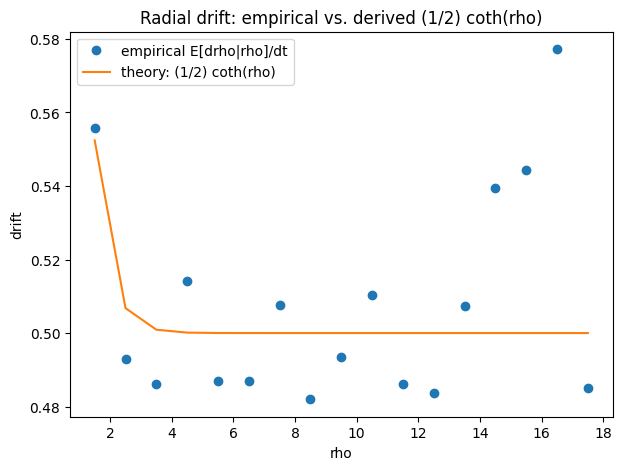

In [15]:
# Visualize the coefficient recovery
plt.figure(figsize=(7, 5))
plt.plot(recovered_rho_centers, recovered_drifts, "o", label="empirical E[drho|rho]/dt")
plt.plot(recovered_rho_centers, recovered_theory_drifts, "-", label="theory: (1/2) coth(rho)")
plt.xlabel("rho")
plt.ylabel("drift")
plt.title("Radial drift: empirical vs. derived (1/2) coth(rho)")
plt.legend()
plt.show()

## Large-$\rho$ asymptotic behavior

As $\rho \to \infty$, $\coth(\rho) \to 1$, so $d\rho \approx d\beta_t + \tfrac12 dt$,
predicting an asymptotic growth *rate* of $1/2$ for $E[\rho_t]$.

We had an interesting and noteworthy finding to document. Our first attempt at this check compared the raw level $E[\rho_{t_{\text{final}}}]$ against
the prediction $t_{\text{final}}/2$ starting from $\rho_0=0$, and it failed by a wide margin (predicted 15.0 at $t=30$, observed $\approx 16.3$). However this is not a contradiction.
$\coth(\rho) > 1$ strictly for every finite $\rho$ and is large for small $\rho$ (diverging as $\rho\to 0$). So the early part of every path, while
still escaping the neighborhood of the origin, accumulates expected $\rho$ faster than the
asymptotic rate, a "head start" on top of the $t/2$ trend, i.e.
$E[\rho_t] \sim t/2 + C$ for a positive constant $C$, not $E[\rho_t] \sim t/2$ exactly. That means comparing a raw level at one finite $t_{\text{final}}$ (starting from $\rho_0=0$) to $t_{\text{final}}/2$ is the wrong approach. The correct test is to compare $\rho$ at two times that are both already well past the initial transient (so $\coth(\rho)\approx 1$ to high precision at
both), and check that the *rate of change* between them is $1/2$, implicitly stating the constant offset $C$ cancels. We use $t_1=15$ and $t_2=30$ (rho reaches roughly 9 and 16 respectively by then, where $\coth(\rho)$ is already within $10^{-4}$ of 1).

In [16]:
N_particles = 4000
T_steps = 3000
dt = 0.01
trajectory = hyperbolic_simulator(T_steps, N_particles, dt)  # shape (T, N, 2)
radii_all = np.linalg.norm(trajectory, axis=2)               # (T, N)
rho_all = np.log((1.0 + radii_all) / (1.0 - radii_all))      # (T, N)

t1_step, t2_step = 1500, 3000  # t = 15 and t = 30
paired_diff = rho_all[t2_step - 1] - rho_all[t1_step - 1]  # per-particle, so we can pair
elapsed = (t2_step - t1_step) * dt

empirical_rate = paired_diff.mean() / elapsed
rate_se = paired_diff.std(ddof=1) / np.sqrt(N_particles) / elapsed

print(f"E[rho] at t=15: {rho_all[t1_step - 1].mean():.4f}")
print(f"E[rho] at t=30: {rho_all[t2_step - 1].mean():.4f}")
print(f"Empirical growth rate between t=15 and t=30: {empirical_rate:.4f} (SE = {rate_se:.4f})")
print(f"Predicted asymptotic rate: 0.5")
print(f"Deviation (SE): {abs(empirical_rate - 0.5) / rate_se:.2f}")

assert abs(empirical_rate - 0.5) < 6 * rate_se

E[rho] at t=15: 9.0875
E[rho] at t=30: 16.4232
Empirical growth rate between t=15 and t=30: 0.4890 (SE = 0.0038)
Predicted asymptotic rate: 0.5
Deviation (SE): 2.89


## Boundary angle uniformity

Almost surely, paths converge to a random point on the boundary circle; this is referred to as the Poisson boundary. Because the hyperbolic metric is rotationally symmetric about the origin, the limiting angle's distribution must be invariant under rotation, hence uniform on $[0, 2\pi)$. We test this uniformity with another KS test against $\mathrm{Uniform}(0, 2\pi)$ using the angular position of particles that have travelled near the boundary.

Particles with radius > 0.8 at t_final: 3995 / 4000
KS statistic: 0.0140, p-value: 0.4126


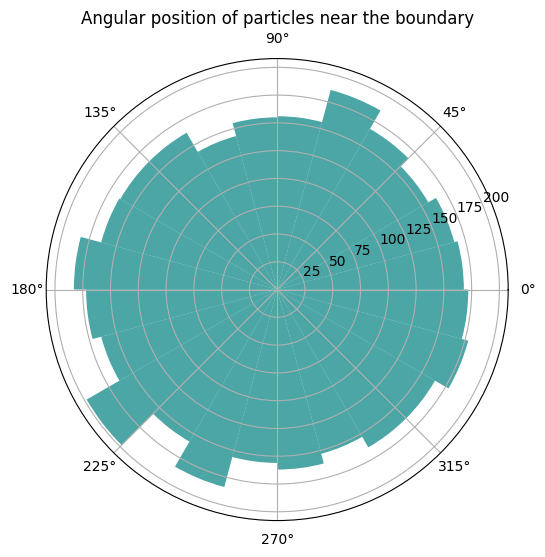

In [ ]:
final_positions = trajectory[-1]
final_radii = radii_all[-1]
near_boundary = final_positions[final_radii > 0.8]
angles = (np.arctan2(near_boundary[:, 1], near_boundary[:, 0])) % (2 * np.pi)
angles_unit_interval = angles / (2 * np.pi)

statistic, p_value = kstest(angles_unit_interval, "uniform")
print(f"Particles with radius > 0.8 at t_final: {len(angles)} / {N_particles}")
print(f"KS statistic: {statistic:.4f}, p-value: {p_value:.4f}")

# A very lenient threshold: we are only checking for gross non-uniformity.
assert p_value > 0.001

plt.figure(figsize=(6, 6))
ax = plt.subplot(111, projection="polar")
counts, bin_edges_angle = np.histogram(angles, bins=24, range=(0, 2 * np.pi))
bin_centers_angle = 0.5 * (bin_edges_angle[:-1] + bin_edges_angle[1:])
ax.bar(bin_centers_angle, counts, width=(2 * np.pi / 24), color="teal", alpha=0.7)
ax.set_title("Angular position of particles near the boundary")
plt.show()

## Summary

- The manifold's structural methods (`project_to_tangent`, `project_to_manifold`) behave
  exactly as documented: the former is a true identity (H^2 is intrinsically 2D), and the
  latter is a rare, shrinking-with-`dt.
- The empirical radial drift and diffusion coefficients recovered from simulated paths match the closed-form targets $\tfrac12\coth(\rho)$ and $1$ derived in
  `docs/writeups/2-poincare-disk-derivation.md`, across the full range of $\rho$ .
- The empirical growth rate of $E[\rho_t]$ matches the predicted rate $t/2$.
- The angular position of particles near the boundary is consistent with the uniform
  distribution predicted by the exact rotational symmetry of the metric.